# The Robert and Rosenbaum Uncertainty Zones model

## Implementation by 
## Marcos Costa Santos Carreira
## École Polytechnique - CMAP
## Feb-2020

### Import packages

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sns

In [8]:
from functools import partial

In [9]:
from scipy import optimize

In [10]:
import datetime as dtt

In [11]:
# import quantecon as qec

In [12]:
import numba as numba

In [13]:
from math import erfc

### Define functions

In [14]:

@numba.jit(nopython=True)
def nprobw(ud, s0, s, α, η, σ, μ, t):
    if t == 0:
        ans = 0
    else:
        ω = μ - 0.5 * σ ** 2
        x0 = np.log(s0)
        bu = np.log(s + (0.5 + η) * α)
        bd = np.log(s - (0.5 + η) * α)
        bpm = bu * (1 + ud) / 2 + bd * (1 - ud) / 2
        bmp = bu * (1 - ud) / 2 + bd * (1 + ud) / 2
        tyzn = 0
        n = 0
        tyznn = 1
        eps=1e-10
        while tyznn > eps:
            n += 1
            yn = ud * (2 * (n - 1) * bmp - (2 * n - 1) * bpm + x0)
            zn = ud * (2 * n * bmp - (2 * n - 1) * bpm - x0)
            tyznn =\
                (np.exp(ω * yn / (σ ** 2)) * erfc(
                -(yn + ω * t) / (σ * np.sqrt(2 * t))) -
                np.exp(ω * zn / (σ ** 2)) * erfc(
                -(zn + ω * t) / (σ * np.sqrt(2 * t))) +
                np.exp(-ω * yn / (σ ** 2)) * erfc(
                -(yn - ω * t) / (σ * np.sqrt(2 * t))) -
                np.exp(-ω * zn / (σ ** 2)) * erfc(
                -(zn - ω * t) / (σ * np.sqrt(2 * t)))) / 2
            tyzn += tyznn
        ans = np.exp(ω * (bpm - x0) / (σ ** 2)) * tyzn
    return ans

In [15]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(nprobw(1, 100, 100, 0.001, 0.25, 0.01, 0, 1))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-04 14:57:51.209161
0.4999999944508164
end
2020-09-04 14:57:51.783558
0:00:00.574397


In [10]:
# nmaxdf = 200

In [11]:

# @numba.jit(nopython=True)
# def nprob(ud, s0, s, α, η, σ, μ, nmax, t):
#     if t == 0:
#         ans = 0
#     else:
#         ω = μ-0.5*σ**2
#         x0 = np.log(s0)
#         bu = np.log(s+(0.5+η)*α)
#         bd = np.log(s-(0.5+η)*α)
#         bpm = bu*(1+ud)/2+bd*(1-ud)/2
#         bmp = bu*(1-ud)/2+bd*(1+ud)/2
#         tyzn = 0
#         for n in range(1, nmax+1):
#             yn = ud*(2*(n-1)*bmp-(2*n-1)*bpm+x0)
#             zn = ud*(2*n*bmp-(2*n-1)*bpm-x0)
#             tyn =\
#                 (np.exp(ω * yn / (σ ** 2)) * erfc(
#                 -(yn + ω * t) / (σ * np.sqrt(2 * t))) +
#                 np.exp(-ω * yn / (σ ** 2)) * erfc(
#                 -(yn - ω * t) / (σ * np.sqrt(2 * t)))) / 2
#             tzn =\
#                 (np.exp( ω * zn / (σ ** 2)) * erfc(
#                 -(zn + ω * t) / (σ * np.sqrt(2 * t))) +
#                 np.exp(-ω * zn / (σ ** 2)) * erfc(
#                 -(zn - ω * t) / (σ * np.sqrt(2 * t)))) / 2
#             tyzn += tyn - tzn
#         ans = np.exp(ω * (bpm - x0) / (σ ** 2)) * tyzn
#         return ans

In [12]:
# print('start')
# currentDT1 = dtt.datetime.now()
# print (str(currentDT1))

# print(nprob(1, 100, 100, 0.001, 0.25, 0.01, 0, nmaxdf, 1))

# print('end')
# currentDT2 = dtt.datetime.now()
# print (str(currentDT2))

# print (str(currentDT2 - currentDT1))

In [16]:
def t_from_p(s0, s, α, η, σ, μ, p):
    '''t_from_p(p, s0, s, α, η, σ, μ) solves the equation
    Pup(t) + Pdown(t) = p; so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change'''
    mprobtup = partial(nprobw, 1, s0, s, α, η, σ, μ)
    mprobtdown = partial(nprobw, -1, s0, s, α, η, σ, μ)
    def groot(t):
        return np.round(mprobtup(t) + mprobtdown(t) - p, decimals=6)
    sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
    return sol.root

In [17]:
def t_from_pud(s0, s, α, η, σ, μ, ud, p):
    '''t_from_pud(p, s0, s, α, η, σ, μ) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
    def groot(t):
        return np.round(mprobt(t)/mprobt(1) - p, decimals=6)
    sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
    return sol.root

In [18]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

t50 = t_from_p(100 + (0.5 - 0.2) * 0.01, 100, 0.01, 0.5, 0.01, 0, 0.999999)
print(t50)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-04 14:57:58.690214
0.00118582470703125
end
2020-09-04 14:57:58.987359
0:00:00.297145


In [19]:
def cdf(s0, s, α, η, σ, μ, npts=100+1):
    grid = np.linspace(0., 0.999, npts)
    pts = pd.Series(grid, index=[t_from_p(s0, s, α, η, σ, μ, p)
                                 for p in grid])
    pts.index.name = 't'
    pts.name = 'CDF(t)'
    return pts

In [20]:
def cdfs(s0, s, α, η, σ, μ, npts=100):
    grid = np.linspace(0, 0.999, npts)
    ts = [t_from_p(s0, s, α, η, σ, μ, p) for p in grid]
    up = [nprobw(+1, s0, s, α, η, σ, μ, t) for t in ts]
    up = np.minimum(up, grid)
    pts = pd.DataFrame({'CDF(t)': grid, 'Up': up, 'Down': grid - up},
                       index=ts)
    pts.index.name = 't'
    # pts.loc[0] = [0., up[0], 1 - up[0]]
    return pts.sort_index()

In [21]:

tcdf = cdfs(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)

In [22]:
def cdfsplot(s0, s, α, η, σ, μ, npts=100+1):
    df = cdfs(s0, s, α, η, σ, μ, npts)
    title = str([s0, s, α, η, σ, μ])
    df.plot(figsize=(9, 6), marker='o', title=title)

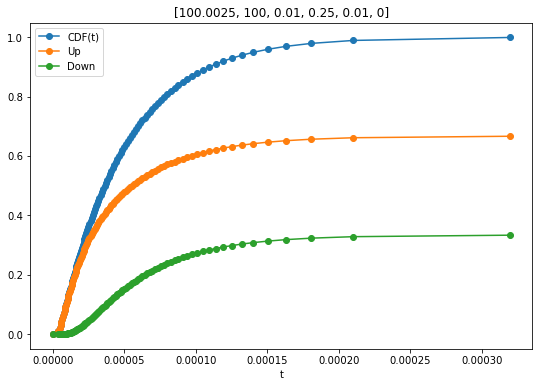

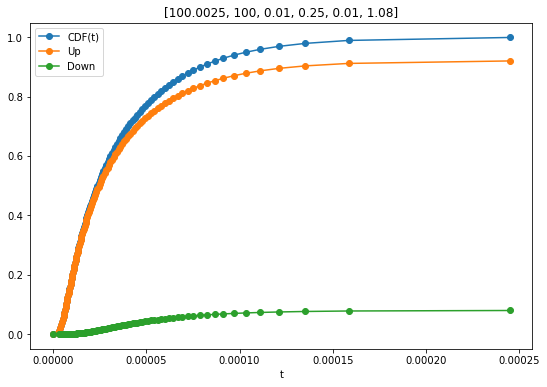

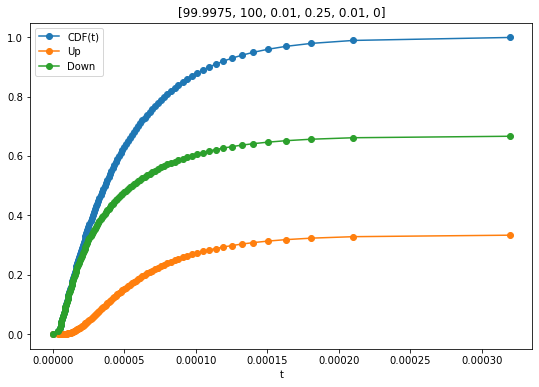

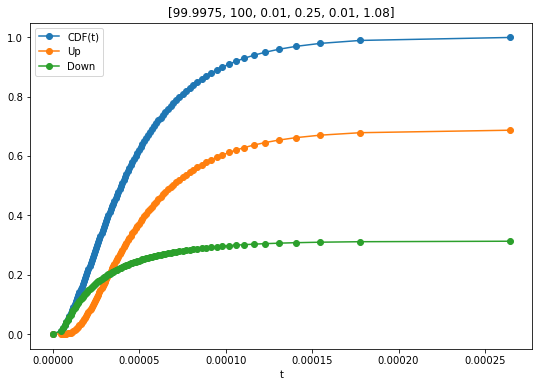

In [23]:

cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
# cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.015, 0)
cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0.002*9*60)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0.002*9*60)

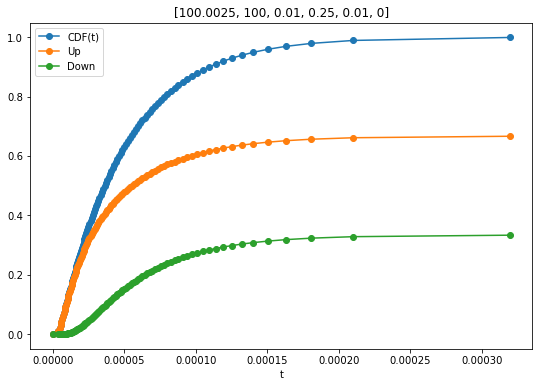

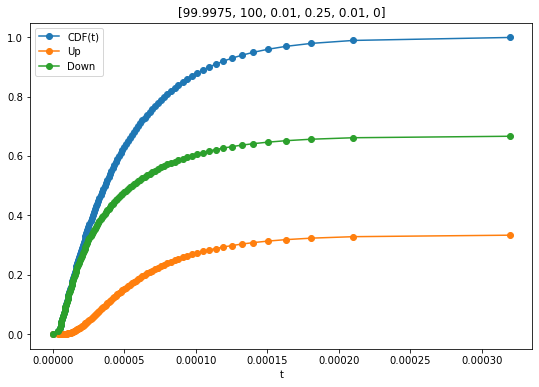

In [24]:

cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)

In [25]:

print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

pts0 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0)
pts1 = cdf(100 + (0.5 - 0.2) * 0.01, 100, 0.01, 0.2, 0.01, 0)
pts2 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0.10)
pts3 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.015, 0)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-04 14:58:26.121201
end
2020-09-04 14:58:26.249968
0:00:00.128767


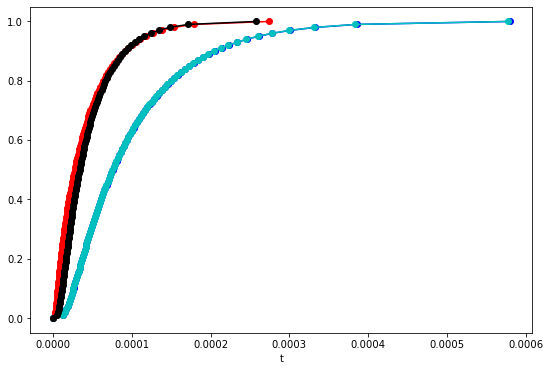

In [26]:

pts0.plot(figsize=(9, 6), color='b', marker='o');
pts1.plot(figsize=(9, 6), color='r', marker='o');
pts2.plot(figsize=(9, 6), color='c', marker='o');
pts3.plot(figsize=(9, 6), color='k', marker='o');

In [ ]:
def up_down(s0, s, α, η, σ, μ, t, p):
    '''up_down(s0, s, α, η, σ, μ, t, p) finds Pup(t) and Pdown(t) with t
    given by solving t_from_p outside the function so that
    for a random p such that 0 <= p <= 1 we choose
    the expected sign (+1 or -1) of a price change'''
    pup = nprobw(1, s0, s, α, η, σ, μ, t)
    pdown = nprobw(-1, s0, s, α, η, σ, μ, t)
    return int(2 * np.heaviside(p - pdown / (pup + pdown), 1) - 1)

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(
      np.array(
          [up_down(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0, t50,
           np.random.uniform(low=0., high=1.)) for j in range(20)]))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:
def next_move(s0, s, α, η, σ, μ):
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_p(s0, s, α, η, σ, μ, p)
    p = np.random.uniform(low=0., high=0.999999)
    ud = up_down(s0, s, α, η, σ, μ, t, p)
    return [t, ud]

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(next_move(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:
def next_state_t(α, η, σ, μ, state):
    sup = state[0]
    s = state[1]
    prev_s = s + sup * (0.5 - η) * α
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_p(prev_s, s, α, η, σ, μ, p)
    p = np.random.uniform(low=0., high=0.999999)
    up = up_down(prev_s, s, α, η, σ, μ, t, p)
    alt = sup == up
    cont = sup != up
    return [[t, s + up * α, up, alt, cont], [-up, s + up * α]]

In [ ]:
def next_state(α, η, σ, μ, state):
    sup = state[0]
    s = state[1]
    prev_s = s + sup * (0.5 - η) * α
    p = np.random.uniform(low=0., high=0.999999)
    up = up_down(prev_s, s, α, η, σ, μ, 1, p)
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_pud(prev_s, s, α, η, σ, μ, up, p)
    alt = sup == up
    cont = sup != up
    return [[t, s + up * α, up, alt, cont], [-up, s + up * α]]

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(next_state(0.01, 0.25, 0.01, 0, [+1, 100]))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:

def simul(s, α, η, σ, μ, T):
    state = [np.random.choice([-1, +1]), s]
    df = pd.DataFrame({'dt': 0, 'P': state[1], 'Sign': 0,
                       'Al': True, 'Co': False}, index=[0])
    n = 1
    while df['dt'].sum() < T:
        row, state = next_state(α, η, σ, μ, state)
        df.loc[n] = row
        n += 1
    df['t'] = df['dt'].cumsum()
    df.set_index('t', inplace=True)
    return df

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

df_simul = simul(100, 0.01, 0.25, 0.01, 0, 1)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:

df_simul['P'].plot()

In [ ]:

def acup_qtl(df):
    df_aup = df[(df['Sign'] == +1) & (df['Al'])]['dt']
    df_cup = df[(df['Sign'] == +1) & (df['Co'])]['dt']
    df_ado = df[(df['Sign'] == -1) & (df['Al'])]['dt']
    df_cdo = df[(df['Sign'] == -1) & (df['Co'])]['dt']
    qtl_rng = np.linspace(0.01, 1.00, 100)
    df_aupq = df_aup.quantile(qtl_rng).reset_index().set_index('dt')
    df_cupq = df_cup.quantile(qtl_rng).reset_index().set_index('dt')
    df_adoq = df_ado.quantile(qtl_rng).reset_index().set_index('dt')
    df_cdoq = df_cdo.quantile(qtl_rng).reset_index().set_index('dt')
    df_aupq.columns = ['p_Al_Up']
    df_cupq.columns = ['p_Co_Up']
    df_adoq.columns = ['p_Al_Do']
    df_cdoq.columns = ['p_Co_Do']
    return [df_aupq, df_cupq, df_adoq, df_cdoq]

In [ ]:

df_quant = acup_qtl(df_simul)
pd.concat(df_quant, axis=1).interpolate().plot()

In [ ]:

def roll_H(df):
    dfc = df.copy()
    dfc['Cum_Al'] = dfc['Al'].cumsum()
    dfc['Cum_Co'] = dfc['Co'].cumsum()
    dfc['H'] = dfc['Cum_Co'] / (2 * dfc['Cum_Al'])
    return dfc['H']

In [ ]:

print(df_simul[['Al', 'Co']].sum())
df_H = roll_H(df_simul)
df_H.plot()

In [ ]:
# def stat_dist(mat):
#     mch = qec.MarkovChain(mat)
#     return mch.stationary_distributions

### Examples

In [18]:
# t_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
t_values = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_values = [0.001, 0.01, 0.1, 1]
eta_values = [0.05, 0.2, 0.35, 0.5]
vol_values = [0.001, 0.01, 0.1]
mu_values = [0, 0.02, 0.10]

In [45]:
stat_dist([[0.4, 0.6], [0.2, 0.8]])

start
2020-08-20 18:55:09.175809
end
2020-08-20 19:10:22.697646


In [ ]:
# X = mc.simulate(ts_length=1_000_000)
# np.mean(X == 0)

In [13]:
# roundprob(1, 100, 100, 0.01, 0.25, 0.01, 0.00005)

In [17]:
inita = np.array([[0,0],[1,1]])

In [19]:
# print('start')
# currentDT = dtt.datetime.now()
# print (str(currentDT))

# testdraw1 = draw(inita, 15, 1, 100, 100, 0.01, 0.25, 0.01)

# print('end')
# currentDT = dtt.datetime.now()
# print (str(currentDT))